# Topic Alignment Scoring

## Pipeline
1. Rebuild and validate the LDA model from EDA
2. Load LLM responses from Notebook 1
3. Score each LLM response against the LDA topic distribution
4. Compute alignment scores per context (SA vs UK)
5. Visualise the results and draw conclusions

## 1. Imports and Configuration

In [15]:
#STANDARD
import os
import warnings
warnings.filterwarnings('ignore')

#DATA HANDLING 
import pandas as pd
import numpy as np

#NLP & TOPIC MODELLING 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import normalize

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel

#VISUALIZATION 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

#DOWNLOAD NLTK DATA
import nltk
nltk.download('punkt',      quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('punkt_tab',  quiet=True)

True

In [16]:
#REFERENCING
EXCEL_PATH = "/Users/thandoluhlemoyo/Desktop/1. MODELLING/articles_combined_Modelling_Final.xlsx"



DATA_PATH = "articles_combined_Modelling.csv"        
LLM_RESPONSES_PATH = "llm_raw_responses.csv" #OUTPUT FROM PREVIOUS CODE

TEXT_COL    = 'article_text'
COUNTRY_COL = 'country'

NUM_TOPICS  = 5    
RANDOM_SEED = 42   

## 2. Load Data

In [17]:
#LOAD DATA
df = pd.read_excel(EXCEL_PATH, sheet_name='additional sa articles')
print(f"Articles dataset: {df.shape}")

#LOAD LLM RESPONSES
llm_df = pd.read_csv(LLM_RESPONSES_PATH)
print(f"LLM responses dataset: {llm_df.shape}")
llm_df.head(3)

Articles dataset: (80, 8)
LLM responses dataset: (30, 5)


,model,scenario_id,scenario_title,context,response
0,Cohere Aya Expanse,S1,Coal employment vs emissions reduction,South Africa,1. **Emission Reduction Bonds**: Provide tax i...
1,Cohere Aya Expanse,S1,Coal employment vs emissions reduction,United Kingdom,1. **Emission Reduction Bonds**: Provide low-i...
2,Cohere Aya Expanse,S2,Drought and rural water access,South Africa,1. **Water Infrastructure Investment**: Increa...


## 3. Text Preprocessing

In [18]:
df.columns

Index(['Link', 'article_id', 'title', 'date', 'article_text', 'URL', 'country',
       'reporting_style'],
      dtype='object')

In [19]:
STOP_WORDS  = set(stopwords.words('english'))
LEMMATIZER  = WordNetLemmatizer()

#ADD DOMAIN SPECIFIC STOPWORDS (DON'T CARRY TOPIC SIGNAL) 
EXTRA_STOPS = {
    'said', 'say', 'year', 'also', 'would', 'could', 'one', 'new',
    'like', 'make', 'need', 'use', 'time', 'way', 'policy', 'recommendation',
    'climate', 'change'}    #WORDS THAT ARE GENERIC AND DONT SIGNAL TOPIC (USUALLY CONTAINED IN MOST ARTICLES)


def preprocess(text: str) -> list:
    """
    Tokenize, lowercase, remove stopwords and short tokens, lemmatize.

    Parameters
    text : Raw text string

    Returns

    list : Cleaned token list
    """
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text.lower())
    tokens = [
        LEMMATIZER.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 2
    ]
    return tokens


#PREPROCESS ARTICLE CORPUS 
df['tokens'] = df[TEXT_COL].apply(preprocess)

#PREPROCESS LLM RESPONSES
llm_df['tokens'] = llm_df['response'].apply(preprocess)

print(f"Sample tokens (article 0): {df['tokens'].iloc[0][:15]}")

Sample tokens (article 0): ['political', 'correspondent', 'south', 'africa', 'formally', 'joined', 'african', 'bank', 'afreximbank', 'lender', 'unveiling', 'support', 'package', 'aligned', 'country']


## 4. Rebuild LDA Model on Article Corpus

In [20]:
#BUILD GENSIM DICTIONARY AND CORPUS 
id2word = corpora.Dictionary(df['tokens'])

#NOISE REDUCTION: IGNORE TOKENS THAT APPEAR IN LESS THAN 2 DOCS OR MORE THAN 90% OF DOCS 
id2word.filter_extremes(no_below=2, no_above=0.9)

corpus = [id2word.doc2bow(tokens) for tokens in df['tokens']]

print(f"Dictionary size  : {len(id2word):,} unique tokens")
print(f"Corpus documents : {len(corpus)}")

Dictionary size  : 3,067 unique tokens
Corpus documents : 80


In [21]:
#TRAIN LDA MODEL 
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=NUM_TOPICS,
    random_state=RANDOM_SEED,   #ENSURE REPRODUCIBILITY 
    passes=20,                  # MORE PASSES = MORE STABLE TOPICS ON SMALL CORPUS 
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

print("LDA model trained. Top words per topic:")

for idx, topic in lda_model.print_topics(num_words=8):
    print(f"  Topic {idx}: {topic}")

LDA model trained. Top words per topic:
  Topic 0: 0.013*"said" + 0.010*"mine" + 0.009*"coal" + 0.008*"south" + 0.008*"africa" + 0.008*"development" + 0.007*"project" + 0.007*"solar"
  Topic 1: 0.016*"said" + 0.014*"coal" + 0.014*"climate" + 0.013*"energy" + 0.009*"south" + 0.009*"power" + 0.008*"change" + 0.007*"africa"
  Topic 2: 0.018*"climate" + 0.013*"water" + 0.012*"said" + 0.009*"change" + 0.009*"year" + 0.006*"wind" + 0.006*"area" + 0.006*"people"
  Topic 3: 0.014*"climate" + 0.010*"water" + 0.009*"south" + 0.008*"africa" + 0.008*"year" + 0.008*"government" + 0.007*"change" + 0.006*"emission"
  Topic 4: 0.009*"sustainable" + 0.009*"said" + 0.009*"energy" + 0.009*"bank" + 0.009*"power" + 0.007*"carbon" + 0.007*"plant" + 0.007*"hydrogen"


## 5. Label Topics Based on EDA Findings

In [22]:
#TOPIC MODELLING (I.E. UPDATE IF LDA ORDER DIFFERS FROM EDA)
TOPIC_LABELS = {
    0: {"name": "Communities & Global",  "alignment": "SA"},
    1: {"name": "Water & Weather",        "alignment": "SA"},
    2: {"name": "New & Local",            "alignment": "UK"},
    3: {"name": "Energy & Emissions",     "alignment": "Neutral"},
    4: {"name": "Policy & Development",   "alignment": "Neutral"},
}

#GROUPING 
SA_TOPIC_IDS  = [tid for tid, info in TOPIC_LABELS.items() if info["alignment"] == "SA"]
UK_TOPIC_IDS  = [tid for tid, info in TOPIC_LABELS.items() if info["alignment"] == "UK"]

print("Topic label mapping:")
for tid, info in TOPIC_LABELS.items():
    print(f"  Topic {tid}: {info['name']} [{info['alignment']}]")

print(f"\nSA topic IDs  : {SA_TOPIC_IDS}")
print(f"UK topic IDs  : {UK_TOPIC_IDS}")

Topic label mapping:
  Topic 0: Communities & Global [SA]
  Topic 1: Water & Weather [SA]
  Topic 2: New & Local [UK]
  Topic 3: Energy & Emissions [Neutral]
  Topic 4: Policy & Development [Neutral]

SA topic IDs  : [0, 1]
UK topic IDs  : [2]


## 6. Score LLM Responses Against the LDA Topic Space

In [23]:
def get_topic_distribution(tokens: list, lda: LdaModel, dictionary: corpora.Dictionary,
                            num_topics: int) -> np.ndarray:
    """
    Use trained LDA model to determine topic probability distribution of a tokenized document

    Parameters
    tokens     : Preprocessed token list
    lda        : Trained Gensim LDA model
    dictionary : Gensim Dictionary fitted on training corpus
    num_topics : Total number of topics in the model

    Returns
   
    np.ndarray : Array of shape (num_topics,) summing to 1.0
    """
    bow = dictionary.doc2bow(tokens)
    if not bow:
        # Return uniform distribution if text has no vocabulary overlap
        return np.full(num_topics, 1.0 / num_topics)

    topic_probs = dict(lda.get_document_topics(bow, minimum_probability=0.0))
    distribution = np.array([topic_probs.get(i, 0.0) for i in range(num_topics)])
    return distribution


#APPLY LLM RESPONSES 
llm_df['topic_distribution'] = llm_df['tokens'].apply(
    lambda tokens: get_topic_distribution(tokens, lda_model, id2word, NUM_TOPICS)
)

#SPLT TOPIC PROBABILITIES INTO SEPARATE COLUMNS 
topic_prob_cols = pd.DataFrame(
    llm_df['topic_distribution'].tolist(),
    columns=[f"topic_{i}_prob" for i in range(NUM_TOPICS)]
)
llm_df = pd.concat([llm_df.reset_index(drop=True), topic_prob_cols], axis=1)

llm_df[['scenario_id', 'context'] + [f"topic_{i}_prob" for i in range(NUM_TOPICS)]].head(6)

,scenario_id,context,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob
0,S1,South Africa,0.000188,0.364004,0.050305,0.479846,0.105656
1,S1,United Kingdom,0.151745,0.405003,0.013561,0.429603,0.000089
2,S2,South Africa,0.000147,0.049726,0.312984,0.459069,0.178073
3,S2,United Kingdom,0.000152,0.176842,0.402950,0.419984,0.000072
4,S3,South Africa,0.155212,0.061691,0.388069,0.394941,0.000088
5,S3,United Kingdom,0.177291,0.000421,0.530025,0.292155,0.000109


## 7. Compute Alignment Scores

In [24]:
def compute_alignment(row: pd.Series, topic_ids: list) -> float:
    """
    Sum the topic probabilities for a set of topic ID = how strongly a response aligns with those topics.

    Parameters
    row       : Dataframe row containing topic_X_prob columns
    topic_ids : List of topic indices to sum

    Returns

    float : Alignment score in [0, 1]
    """
    return sum(row[f"topic_{i}_prob"] for i in topic_ids)


llm_df['sa_alignment']  = llm_df.apply(lambda r: compute_alignment(r, SA_TOPIC_IDS),  axis=1)
llm_df['uk_alignment']  = llm_df.apply(lambda r: compute_alignment(r, UK_TOPIC_IDS),  axis=1)

#BIAS DIRECTION SCORE Bias direction score: positive = more SA-aligned, negative = more UK-aligned (GN bias)
llm_df['alignment_delta'] = llm_df['sa_alignment'] - llm_df['uk_alignment']

print("Alignment scores per LLM response:")
print(llm_df[['scenario_id', 'context', 'sa_alignment',
              'uk_alignment', 'alignment_delta']].to_string(index=False))

Alignment scores per LLM response:
scenario_id        context  sa_alignment  uk_alignment  alignment_delta
         S1   South Africa      0.364193      0.050305         0.313888
         S1 United Kingdom      0.556748      0.013561         0.543187
         S2   South Africa      0.049873      0.312984        -0.263111
         S2 United Kingdom      0.176994      0.402950        -0.225955
         S3   South Africa      0.216903      0.388069        -0.171166
         S3 United Kingdom      0.177711      0.530025        -0.352313
         S4   South Africa      0.330065      0.022446         0.307619
         S4 United Kingdom      0.524026      0.077881         0.446145
         S5   South Africa      0.536216      0.069800         0.466416
         S5 United Kingdom      0.405195      0.153128         0.252068
         S1   South Africa      0.757267      0.080323         0.676945
         S1 United Kingdom      0.474172      0.057756         0.416417
         S2   South Africa   

In [25]:
#AGGREGATED ALIGNMENT BASED ON CONTEXT 
alignment_summary = llm_df.groupby('context')[[
    'sa_alignment', 'uk_alignment', 'alignment_delta'
]].mean().round(4)

print("\nMean alignment scores by context:")
print(alignment_summary)
print()



Mean alignment scores by context:
                sa_alignment  uk_alignment  alignment_delta
context                                                    
South Africa          0.3303        0.1838           0.1465
United Kingdom        0.3117        0.2248           0.0869



In [26]:
#ALIGNMENT SCORE ACCORDING TO SCENARIO ALIGNMENT 
scenario_alignment = llm_df.groupby(['scenario_id', 'context'])[
    ['sa_alignment', 'uk_alignment', 'alignment_delta']
].mean().round(4)

print("Alignment scores per scenario and context:")
print(scenario_alignment.to_string())

Alignment scores per scenario and context:
                            sa_alignment  uk_alignment  alignment_delta
scenario_id context                                                    
S1          South Africa          0.6087        0.0436           0.5650
            United Kingdom        0.5355        0.0462           0.4893
S2          South Africa          0.0636        0.3353          -0.2717
            United Kingdom        0.1195        0.4172          -0.2977
S3          South Africa          0.1572        0.4322          -0.2750
            United Kingdom        0.1946        0.4928          -0.2983
S4          South Africa          0.2856        0.0378           0.2478
            United Kingdom        0.3466        0.0320           0.3146
S5          South Africa          0.5364        0.0699           0.4665
            United Kingdom        0.3623        0.1356           0.2267


## 8. Visualisations

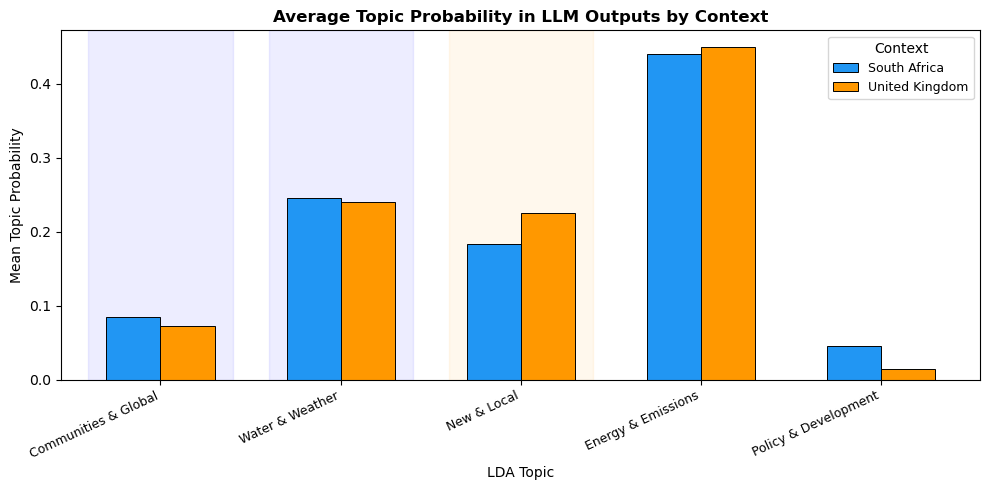

In [27]:
#AVERAGE TOPIC DISTRIBUTION BY CONTEXT 
topic_means = llm_df.groupby('context')[
    [f"topic_{i}_prob" for i in range(NUM_TOPICS)]
].mean()


topic_means.columns = [TOPIC_LABELS[i]["name"] for i in range(NUM_TOPICS)]

#COLOR TOPICS BY REGION 
alignment_colors = {
    "SA"      : ["#1565C0", "#42A5F5"],   
    "UK"      : ["#E65100"],              
    "Neutral" : ["#757575", "#BDBDBD"],   
}
bar_colors = []
sa_count, uk_count, neu_count = 0, 0, 0
for i in range(NUM_TOPICS):
    alignment = TOPIC_LABELS[i]["alignment"]
    if alignment == "SA":
        bar_colors.append(alignment_colors["SA"][sa_count % 2]);  sa_count += 1
    elif alignment == "UK":
        bar_colors.append(alignment_colors["UK"][uk_count % 1]);  uk_count += 1
    else:
        bar_colors.append(alignment_colors["Neutral"][neu_count % 2]);  neu_count += 1

fig, ax = plt.subplots(figsize=(10, 5))
topic_means.T.plot(
    kind='bar', ax=ax,
    color=["#2196F3", "#FF9800"],   
    width=0.6, edgecolor='black', linewidth=0.7
)

ax.set_title("Average Topic Probability in LLM Outputs by Context",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Mean Topic Probability", fontsize=10)
ax.set_xlabel("LDA Topic", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
ax.legend(title="Context", fontsize=9)

for i, (topic_name, info) in enumerate([
    (TOPIC_LABELS[j]["name"], TOPIC_LABELS[j]) for j in range(NUM_TOPICS)
]):
    if info["alignment"] == "SA":
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.07, color='blue', zorder=0)
    elif info["alignment"] == "UK":
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.07, color='orange', zorder=0)

plt.tight_layout()
plt.savefig("fig4_topic_distribution_by_context.png", dpi=150, bbox_inches='tight')
plt.show()

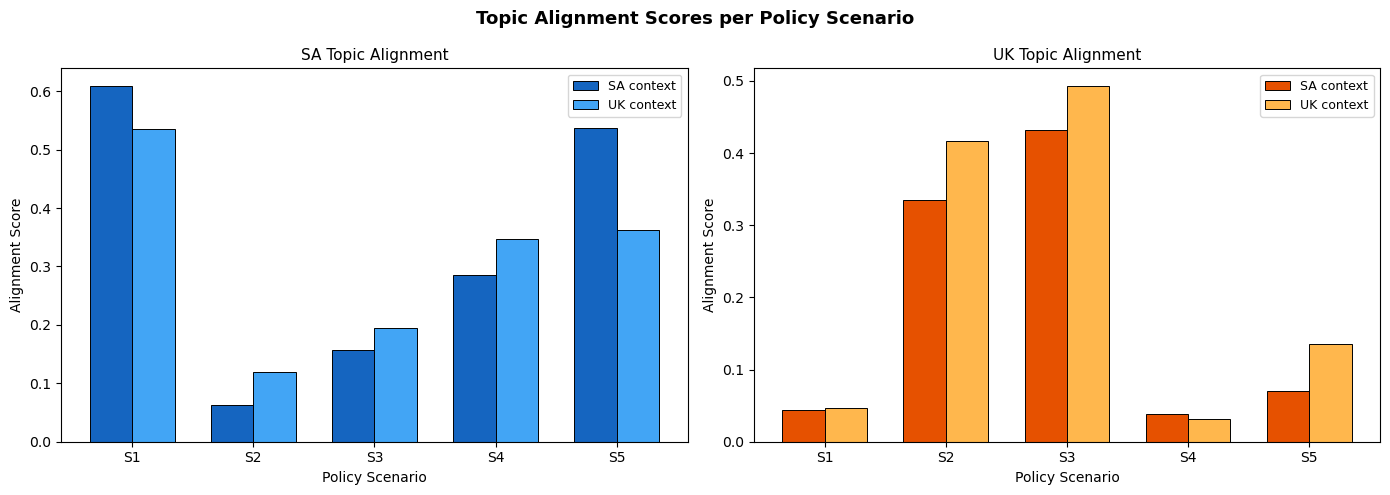

In [28]:
#SA vs UK ALIGNMENT SCORE PER SCENARIO 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Topic Alignment Scores per Policy Scenario", fontsize=13, fontweight='bold')

scenarios = llm_df['scenario_id'].unique()
x = np.arange(len(scenarios))
width = 0.35

for ax_idx, (metric, title, color_sa, color_uk) in enumerate([
    ('sa_alignment', 'SA Topic Alignment', '#1565C0', '#42A5F5'),
    ('uk_alignment', 'UK Topic Alignment', '#E65100', '#FFB74D'),
]):
    ax = axes[ax_idx]
    sa_vals = [
        llm_df[(llm_df['scenario_id'] == s) & (llm_df['context'] == 'South Africa')][metric].mean()
        for s in scenarios
    ]
    uk_vals = [
        llm_df[(llm_df['scenario_id'] == s) & (llm_df['context'] == 'United Kingdom')][metric].mean()
        for s in scenarios
    ]

    ax.bar(x - width/2, sa_vals, width, label='SA context', color=color_sa,
           edgecolor='black', linewidth=0.7)
    ax.bar(x + width/2, uk_vals, width, label='UK context', color=color_uk,
           edgecolor='black', linewidth=0.7)

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios)
    ax.set_xlabel("Policy Scenario", fontsize=10)
    ax.set_ylabel("Alignment Score", fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig5_alignment_per_scenario.png", dpi=150, bbox_inches='tight')
plt.show()


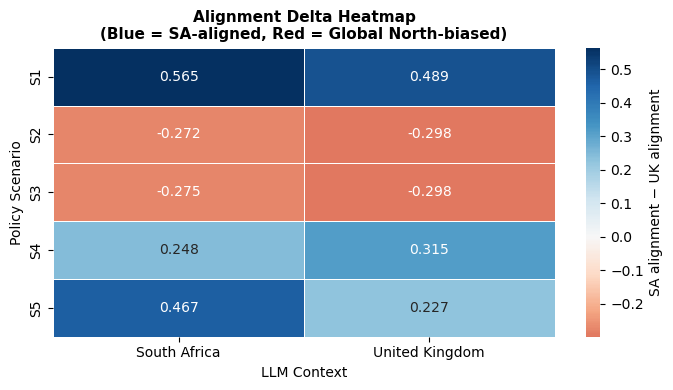

In [29]:
#ALIGNMENT DIFFERENCE HEATMAP 
# Difference is ---> Delta = SA alignment − UK alignment
# Positive (blue) = SA aligned AND  Negative (red) = UK biased

heatmap_data = llm_df.pivot_table(
    index='scenario_id', columns='context', values='alignment_delta'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap='RdBu',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'SA alignment − UK alignment'}
)
ax.set_title(
    "Alignment Delta Heatmap\n(Blue = SA-aligned, Red = Global North-biased)",
    fontsize=11, fontweight='bold'
)
ax.set_ylabel("Policy Scenario", fontsize=10)
ax.set_xlabel("LLM Context", fontsize=10)

plt.tight_layout()
plt.savefig("fig6_alignment_delta_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Article Baseline

In [30]:
#COMPUTE TOPIC DISTRIBUTIONS FOR ARTICLES 
df['topic_distribution'] = df['tokens'].apply(
    lambda tokens: get_topic_distribution(tokens, lda_model, id2word, NUM_TOPICS)
)

article_topic_cols = pd.DataFrame(
    df['topic_distribution'].tolist(),
    columns=[f"topic_{i}_prob" for i in range(NUM_TOPICS)]
)
df = pd.concat([df.reset_index(drop=True), article_topic_cols], axis=1)

df['sa_alignment'] = df.apply(lambda r: compute_alignment(r, SA_TOPIC_IDS), axis=1)
df['uk_alignment'] = df.apply(lambda r: compute_alignment(r, UK_TOPIC_IDS), axis=1)
df['alignment_delta'] = df['sa_alignment'] - df['uk_alignment']

#AGGREGATE BY COUNTRY 
article_baseline = df.groupby(COUNTRY_COL)[[
    'sa_alignment', 'uk_alignment', 'alignment_delta'
]].mean().round(4)

print("Article baseline alignment by country:")
print(article_baseline)

Article baseline alignment by country:
                sa_alignment  uk_alignment  alignment_delta
country                                                    
South Africa          0.4664        0.1329           0.3335
United Kingdom        0.2886        0.3808          -0.0923


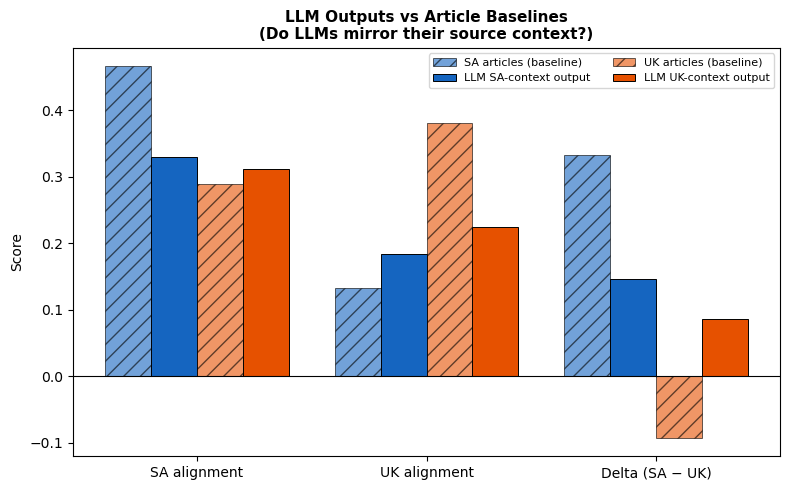

In [31]:
#LLM OUTPUT VS ARTICLE BASELINE 
fig, ax = plt.subplots(figsize=(8, 5))

categories    = ['SA alignment', 'UK alignment', 'Delta (SA − UK)']
llm_sa_means  = alignment_summary.loc['South Africa'].values
llm_uk_means  = alignment_summary.loc['United Kingdom'].values

sa_mask = article_baseline.index.str.contains('South Africa', case=False)
uk_mask = article_baseline.index.str.contains('United Kingdom|UK', case=False)
baseline_sa = article_baseline[sa_mask].values[0] if sa_mask.any() else [0, 0, 0]
baseline_uk = article_baseline[uk_mask].values[0] if uk_mask.any() else [0, 0, 0]

x       = np.arange(len(categories))
width   = 0.2

ax.bar(x - width*1.5, baseline_sa, width, label='SA articles (baseline)',
       color='#1565C0', alpha=0.6, edgecolor='black', linewidth=0.7, hatch='//')
ax.bar(x - width*0.5, llm_sa_means, width, label='LLM SA-context output',
       color='#1565C0', edgecolor='black', linewidth=0.7)
ax.bar(x + width*0.5, baseline_uk, width, label='UK articles (baseline)',
       color='#E65100', alpha=0.6, edgecolor='black', linewidth=0.7, hatch='//')
ax.bar(x + width*1.5, llm_uk_means, width, label='LLM UK-context output',
       color='#E65100', edgecolor='black', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("LLM Outputs vs Article Baselines\n(Do LLMs mirror their source context?)",
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("fig7_llm_vs_baseline.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. PCS Check: Stability of LDA Topics

In [32]:
#TEST LDA STABILITY
# NOTE:If top words are consistent across seeds = the topics are stable

SEEDS = [42, 123, 999]
top_words_per_seed = {}

for seed in SEEDS:
    model_temp = LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=NUM_TOPICS,
        random_state=seed,
        passes=20,
        alpha='auto',
        eta='auto'
    )
    top_words_per_seed[seed] = [
        set(word for word, _ in model_temp.show_topic(i, topn=5))
        for i in range(NUM_TOPICS)
    ]

#COMPUTE JACCARD OVERLAP PER TOPIC 
print("LDA Stability: Jaccard similarity of top-5 words")
print("-" * 55)
print(f"{'Topic':<10} {'Seed 42 vs 123':>18} {'Seed 42 vs 999':>18}")
print("-" * 55)

for i in range(NUM_TOPICS):
    words_42  = top_words_per_seed[42][i]
    words_123 = top_words_per_seed[123][i]
    words_999 = top_words_per_seed[999][i]

    def jaccard(a, b):
        return round(len(a & b) / len(a | b), 3) if (a | b) else 0.0

    j1 = jaccard(words_42, words_123)
    j2 = jaccard(words_42, words_999)
    label = TOPIC_LABELS[i]['name']
    print(f"{label:<22} {j1:>10.3f}       {j2:>10.3f}")

print("-" * 55)
print("Jaccard = 1.0: identical top words. ≥ 0.6 = stable topic.")

LDA Stability: Jaccard similarity of top-5 words
-------------------------------------------------------
Topic          Seed 42 vs 123     Seed 42 vs 999
-------------------------------------------------------
Communities & Global        0.111            0.429
Water & Weather             0.250            0.250
New & Local                 0.429            0.429
Energy & Emissions          0.429            0.250
Policy & Development        0.429            0.000
-------------------------------------------------------
Jaccard = 1.0: identical top words. ≥ 0.6 = stable topic.


## 11. Save Outputs

In [33]:
llm_df.drop(columns=['tokens', 'topic_distribution'], errors='ignore').to_csv(
    "topic_alignment_scores.csv", index=False
)
alignment_summary.to_csv("alignment_summary.csv")
article_baseline.to_csv("article_baseline_alignment.csv")